✅ Đã kết nối MySQL và đọc thành công 30,336 bản ghi từ bảng 'aqi_data'


11:06:08 - cmdstanpy - INFO - Chain [1] start processing
11:06:23 - cmdstanpy - INFO - Chain [1] done processing


📸 Hệ thống: Đã chụp và ép lưu ảnh 48 giờ răng cưa thành công tại -> C:\Users\BUI QUANG HUNG\Air-Quality-Index-in-Hanoi-\charts\prophet_forecast.png


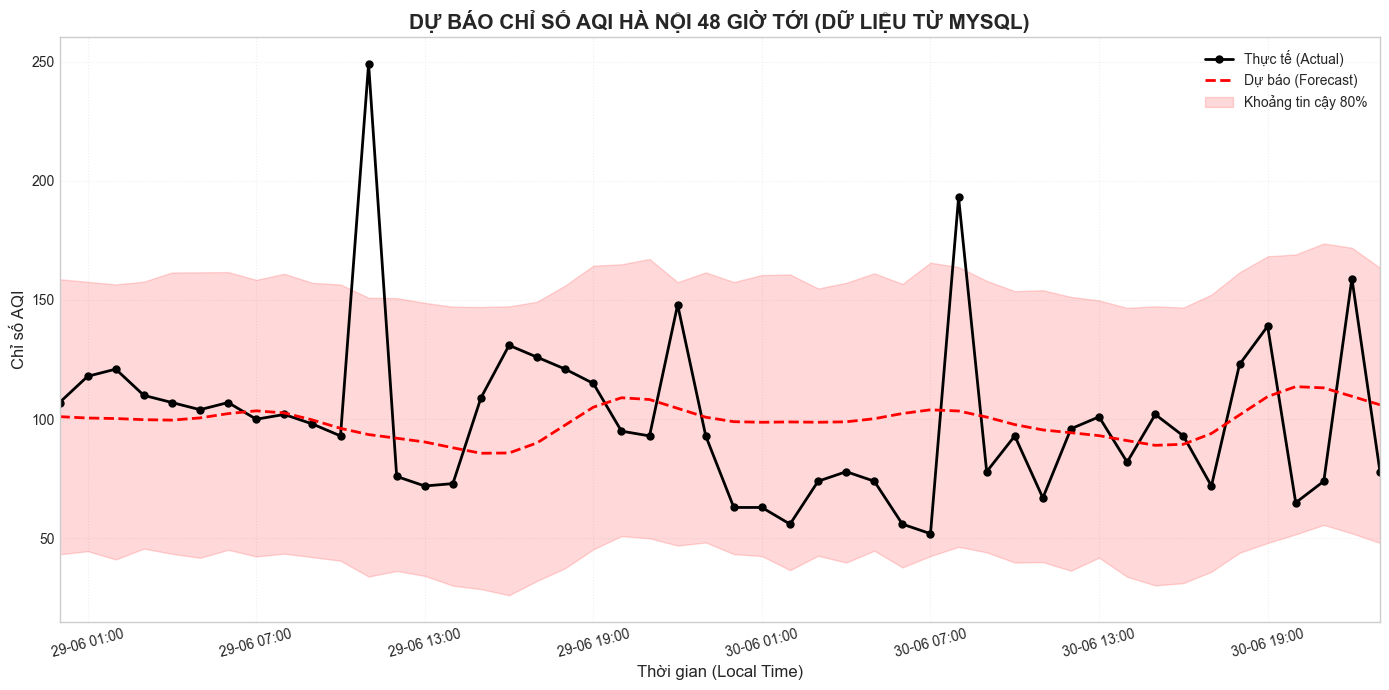

Hệ thống: Hoàn thành chạy dự báo vận hành dựa trên nguồn dữ liệu SQL.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sqlalchemy import create_engine
import warnings
import os
from dotenv import load_dotenv
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)

current_dir = Path(os.getcwd()).resolve()
if 'library_framework' in current_dir.parts:
    dotenv_path = current_dir.parent / '.env'
    # SỬA ĐƯỜNG DẪN: Ép thư mục charts phải nhảy ra ngoài thư mục gốc để Streamlit ăn ảnh chuẩn
    charts_dir = current_dir.parent / 'charts'
else:
    dotenv_path = current_dir / '.env'
    charts_dir = current_dir / 'charts'

load_dotenv(dotenv_path=dotenv_path)
os.makedirs(charts_dir, exist_ok=True)

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

try:
    query = "SELECT local_time, aqi FROM aqi_data"
    df = pd.read_sql(query, con=engine)
    print(f"✅ Đã kết nối MySQL và đọc thành công {len(df):,} bản ghi từ bảng 'aqi_data'")
except Exception as e:
    print(f"❌ Lỗi kết nối hoặc không tìm thấy bảng sạch: {e}")

df.columns = df.columns.str.strip().str.lower()
df['ds'] = pd.to_datetime(df['local_time'])
df['y'] = pd.to_numeric(df['aqi'], errors='coerce')
df = df.dropna(subset=['ds', 'y'])

test_size = 48
train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(train)

future = model.make_future_dataframe(periods=test_size, freq='h')
forecast = model.predict(future)

# =================================================================
# PHÂN HỆ VẼ ĐỒ THỊ VÀ ÉP PHÓNG TO KHUNG HÌNH 48 GIỜ RĂNG CƯA CHUẨN
# =================================================================
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(test['ds'], test['y'], label='Thực tế (Actual)', color='black', marker='o', markersize=5, linewidth=2)

ax.plot(forecast['ds'].tail(test_size), forecast['yhat'].tail(test_size), label='Dự báo (Forecast)', color='red', linestyle='--', linewidth=2)

ax.fill_between(forecast['ds'].tail(test_size), forecast['yhat_lower'].tail(test_size), forecast['yhat_upper'].tail(test_size), color='red', alpha=0.15, label='Khoảng tin cậy 80%')

start_date = test['ds'].min()
end_date = test['ds'].max()
ax.set_xlim(start_date, end_date)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))  # Cứ cách 6 tiếng vạch 1 mốc giờ
plt.xticks(rotation=15)
# ----------------------------------------------------------------------

plt.title('DỰ BÁO CHỈ SỐ AQI HÀ NỘI 48 GIỜ TỚI (DỮ LIỆU TỪ MYSQL)', fontsize=15, fontweight='bold')
plt.xlabel('Thời gian (Local Time)', fontsize=12)
plt.ylabel('Chỉ số AQI', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3, linestyle=':')
plt.tight_layout()

# --- TIẾN HÀNH CHỤP VÀ LƯU ĐÈ ẢNH CẬN CẢNH RA GIAO DIỆN WEB ---
output_image_path = os.path.join(charts_dir, 'prophet_forecast.png')
plt.savefig(output_image_path, bbox_inches='tight', dpi=300)  # Để độ phân giải siêu nét 300dpi
print(f"📸 Hệ thống: Đã chụp và ép lưu ảnh 48 giờ răng cưa thành công tại -> {output_image_path}")

plt.show()  # Hiển thị trực tiếp output đồng bộ dưới ô code Notebook

print(f"Hệ thống: Hoàn thành chạy dự báo vận hành dựa trên nguồn dữ liệu SQL.")